In [21]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import Utilities as utils


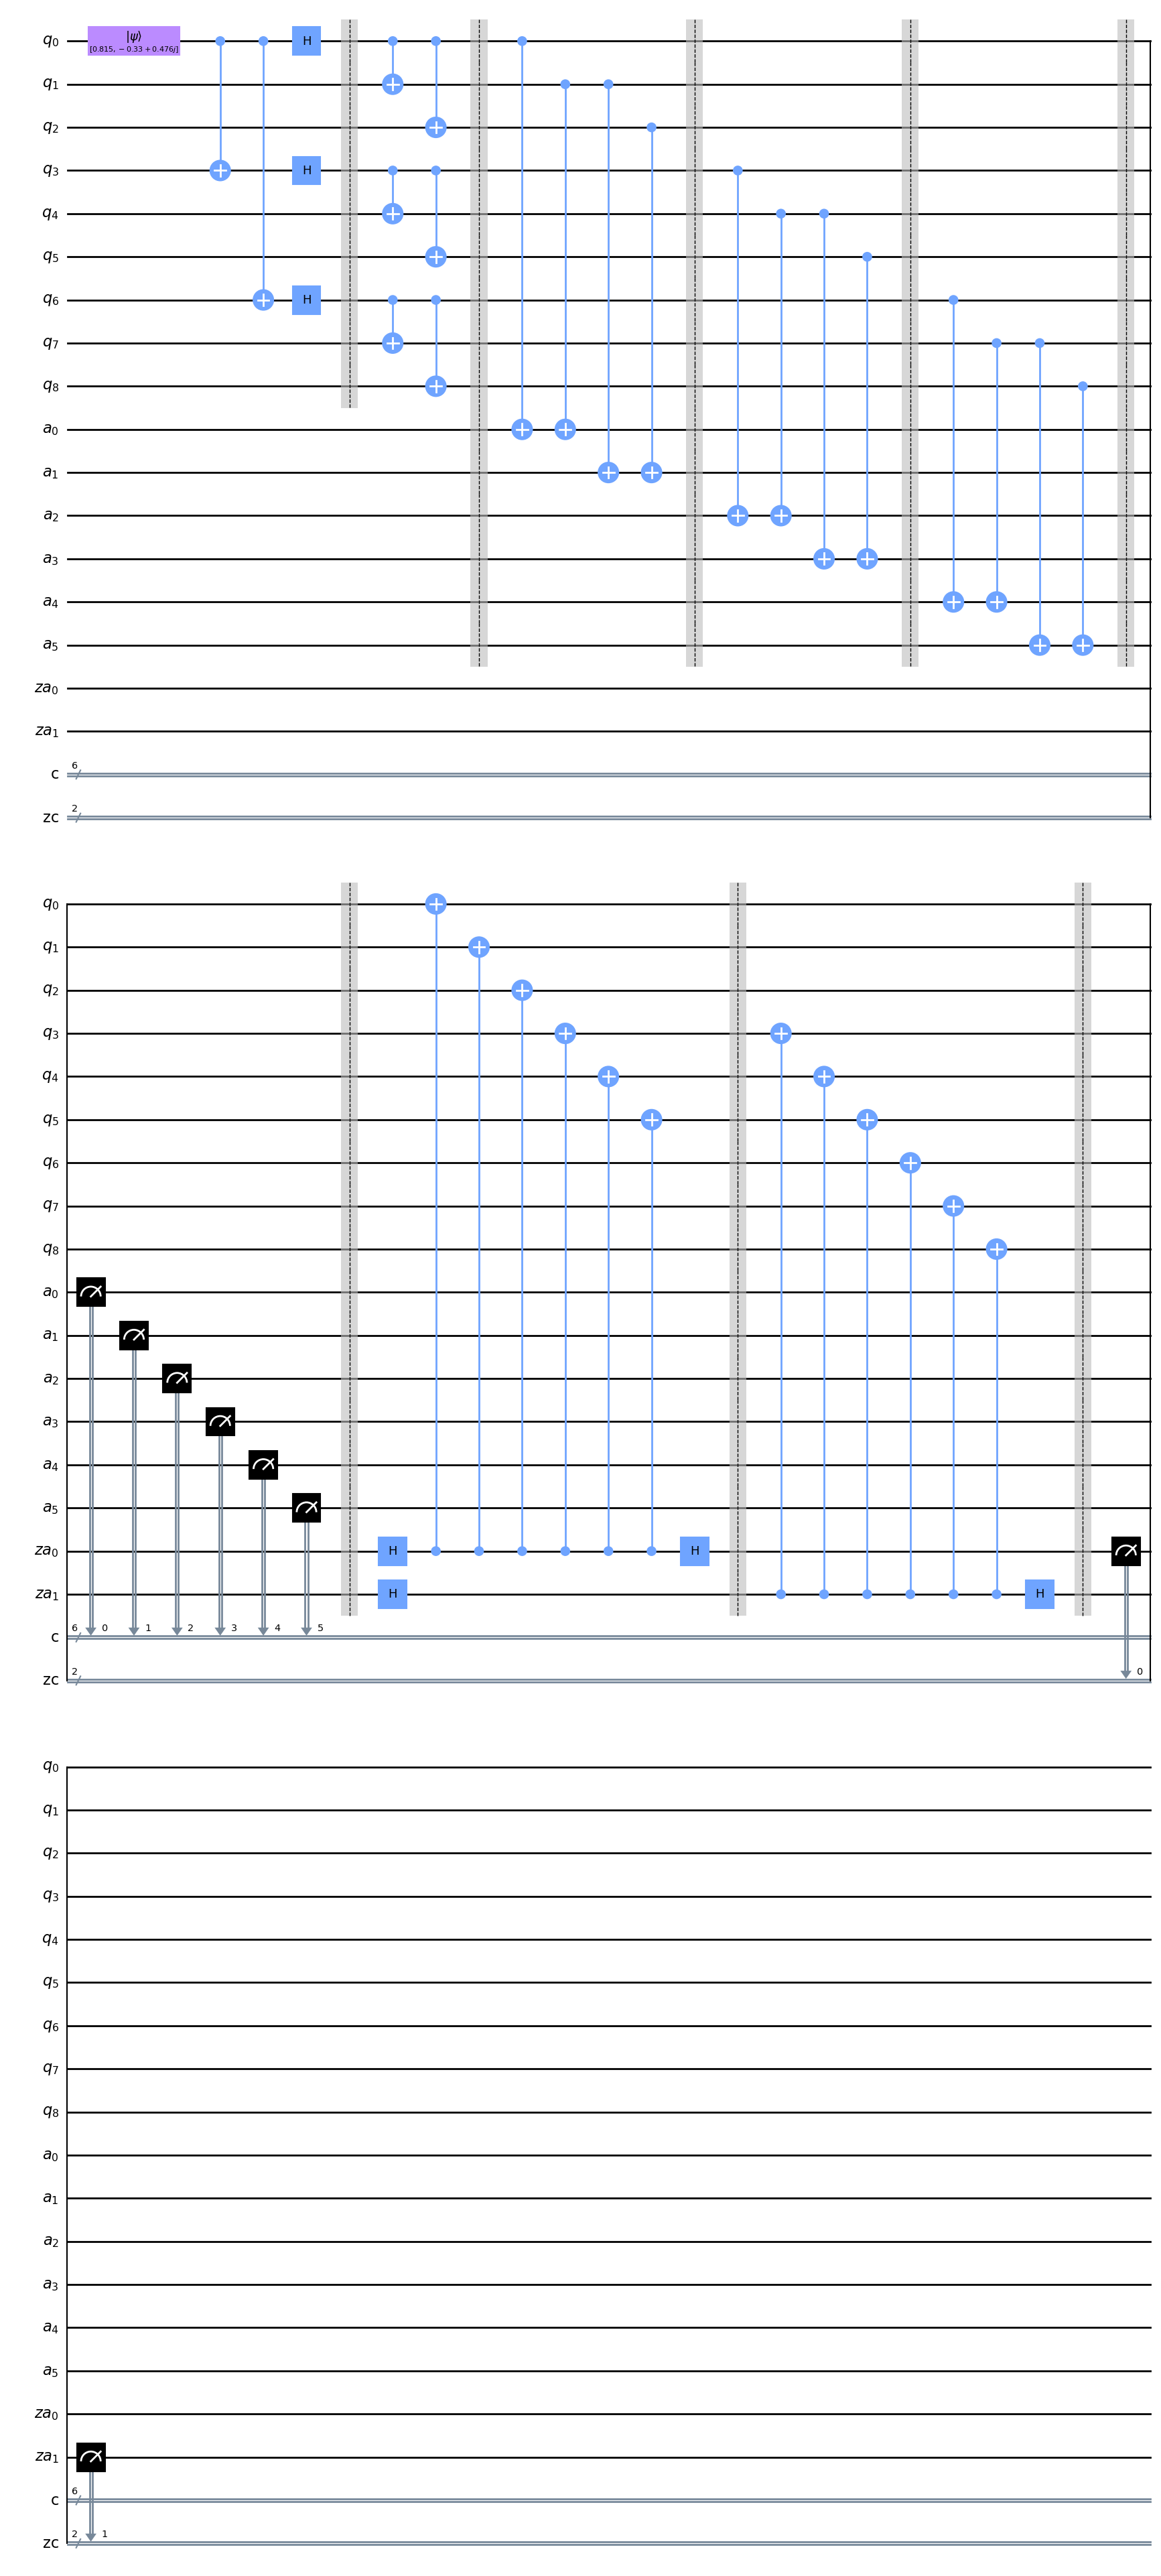

Expected: {'00 000000': 1}, Got: {'00 000000': 1}
Expected: {'00 000011': 1}, Got: {'00 000011': 1}
Expected: {'11 000000': 1}, Got: {'11 000000': 1}


In [ ]:
def encode():
    # create arbitrary state |ψ⟩ = α|0⟩ + β|1⟩
    theta = np.random.uniform(0, np.pi)
    phi = np.random.uniform(0, 2 * np.pi)
    alpha = np.cos(theta / 2)
    beta = np.exp(1j*phi) * np.sin(theta / 2)
    # this is of the form |ψ⟩ = cos(θ/2)|0⟩ + e^(iφ)sin(θ/2)|1⟩

    #print(f"|α|² + |β|² = {abs(alpha)**2 + abs(beta)**2:.6f}")  # should be 1.0

    qc = QuantumCircuit(9)
    
    # the Z phase flip layer - Outer layer
    qc.initialize([alpha, beta], 0)  # initialize first qubit to |ψ⟩
    qc.cx(0,3)
    qc.cx(0,6)
    qc.h([0, 3, 6])
    qc.barrier()

    # creating the inner block for bit flip now
    qc.cx(0,1); qc.cx(0,2)
    qc.cx(3,4); qc.cx(3,5)
    qc.cx(6,7); qc.cx(6,8)

    return qc

def syndrome_x_measurement(qc):
    # create the measurement syndrome
    a = QuantumRegister(6, 'a')
    c = ClassicalRegister(6, 'c')
    qc.add_register(a)
    qc.add_register(c)
    qc.barrier()
    # measure the bit flip error syndrome
    # block 0, q0, q1, q2 on a0 and a1
    qc.cx(0, a[0]); qc.cx(1,a[0])
    qc.cx(1, a[1]); qc.cx(2, a[1])
    qc.barrier()
    
    # block 1, q3, q4, q5 on a2 and a3
    qc.cx(3, a[2]); qc.cx(4,a[2])
    qc.cx(4, a[3]); qc.cx(5, a[3])
    qc.barrier()

    # block 2, q6, q7, q8 on a4 and a5
    qc.cx(6, a[4]); qc.cx(7,a[4])
    qc.cx(7, a[5]); qc.cx(8, a[5])
    qc.barrier()
    
    qc.measure(a, c)

    return qc


def syndrome_z_measurement(qc):
    a = QuantumRegister(2, 'za')
    c = ClassicalRegister(2, 'zc')
    qc.add_register(a)
    qc.add_register(c)
    qc.barrier()
    qc.h(a)
    # measure the phase flip error syndrome
    # measure block 0 vs block 1
    qc.cx(a[0],0); qc.cx(a[0], 1); qc.cx(a[0], 2)
    qc.cx(a[0], 3); qc.cx(a[0], 4); qc.cx(a[0], 5)
    qc.h(a[0])
    qc.barrier()

    # measure block 1 vs block 2
    qc.cx(a[1],3); qc.cx(a[1], 4); qc.cx(a[1], 5)
    qc.cx(a[1], 6); qc.cx(a[1], 7); qc.cx(a[1], 8)
    qc.h(a[1])
    qc.barrier()

    qc.measure(a, c)

    return qc


qc = syndrome_z_measurement(syndrome_x_measurement(encode()))
display(qc.draw('mpl', style="Clifford"))

# quick test for no error case - ideal

sim = AerSimulator()
counts = sim.run(qc, shots=1).result().get_counts()
print(f"No error case: Expected: {{'00 000000': 1}}, Got: {counts}")
# expected: {'00 000000': 1}

# Inject X error in middle qwubit Block 0
qc = encode()
qc.x(1)           # bit flip on q1 (middle of block 0)
qc = syndrome_x_measurement(qc)
qc = syndrome_z_measurement(qc)

result = sim.run(qc, shots=1).result()
print(f"X error in middle qubit block 0 case: Expected: {{'00 000011': 1}}, Got: {result.get_counts()}")
# expected: {'00 000011': 1}
# c[0]=1 (q0⊕q1=1), c[1]=1 (q1⊕q2=1) → middle qubit of block 0

qc = encode()
qc.z(3)           # phase flip on block 1 representative
qc = syndrome_x_measurement(qc)
qc = syndrome_z_measurement(qc)

result = sim.run(qc, shots=1).result()
print(f"Z error in block 1 case: Expected: {{'11 000000': 1}}, Got: {result.get_counts()}")
# expected: {'11 000000': 1}
# zc[0]=1 (block0 vs block1 differ), zc[1]=1 (block1 vs block2 differ)



